In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import cv2
import math
import matplotlib.colors as colors

In [8]:
def BC(hist1, hist2):
    hist1 = hist1 / np.sum(hist1)
    hist2 = hist2 / np.sum(hist2)
    BC = np.sum(np.sqrt(hist1 * hist2))
    return BC



In [9]:
# open video file (use VideoCapture, not imread)
vidCapture = cv2.VideoCapture('case.mp4')
# vidCapture = cv2.VideoCapture('rubics.mp4')
# vidCapture = cv2.VideoCapture('walk.mp4')
# vidCapture = cv2.VideoCapture('walksit.mp4')
# vidCapture = cv2.VideoCapture('test_person.mp4')

ret, frame = vidCapture.read()
if not ret:
    raise ValueError("Could not read video")

# Let user select ROI
x, y, w, h = cv2.selectROI("Select Object", frame, fromCenter=False)
cv2.destroyWindow("Select Object")

# Reset video to start
vidCapture.set(cv2.CAP_PROP_POS_FRAMES, 0)

track_window = (x, y, w, h)



Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!


m00_0: 8611.156
8611.156


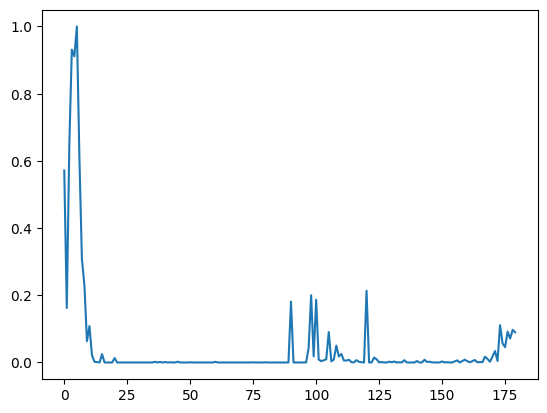

In [10]:
roi = frame[y:y+h, x:x+w]
hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
hist_target = cv2.calcHist([hsv_roi], [0], None, [180], [0, 180]).astype(np.float32)
cv2.normalize(hist_target, hist_target, 0, 1, cv2.NORM_MINMAX)

initial_prob_map = cv2.calcBackProject([cv2.cvtColor(frame.astype(np.float32), cv2.COLOR_BGR2HSV)], [0], hist_target, [0,180], 1)

# print(initial_prob_map)
m00_0 = np.sum(initial_prob_map[y:y+h, x:x+w])
print("m00_0:", m00_0)

r1 = w / math.sqrt(m00_0)
r2 = h / math.sqrt(m00_0)
print(m00_0)

plt.plot(hist_target)
plt.show()


In [11]:
max_iters = 100

while True:
    ret, frame = vidCapture.read()
    if not ret:
        break

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    prob_map = cv2.calcBackProject([hsv], [0], hist_target, [0,180], 1)
    prob_map = prob_map.astype(np.float32)   # DO NOT NORMALIZE TO 0–1

    for _ in range(max_iters):
        x, y, w, h = track_window

        window = prob_map[y:y+h, x:x+w]

        m00 = np.sum(window)
        if m00 < 1e-3:
            break

        # moments in window coordinates
        M01 = np.sum(np.arange(w)[None, :] * window)    # x-weighted
        M10 = np.sum(np.arange(h)[:, None] * window)    # y-weighted

        xc = M01 / m00
        yc = M10 / m00


        # correct centroid → global frame
        new_x = int(x + xc - w/2)
        new_y = int(y + yc - h/2)

        height, width = frame.shape[:2]
        new_x = max(0, min(new_x, width - w))
        new_y = max(0, min(new_y, height - h))

        if abs(new_x - x) < 1 and abs(new_y - y) < 1:
            break

        track_window = (new_x, new_y, w, h)
    
    # new_w = int(r1 * math.sqrt(m00))
    # new_h = int(r2 * math.sqrt(m00))

    # x, y, _, _ = track_window

    # # Clamp width/height so box stays inside image
    # H, W = frame.shape[:2]

    # # Adjust width/height if they overflow
    # if x + new_w > W:
    #     new_w = W - x
    # if y + new_h > H:
    #     new_h = H - y

    # # Enforce minimum window size (avoid collapse)
    # new_w = max(new_w, 10)
    # new_h = max(new_h, 10)

    # track_window = (x, y, new_w, new_h)
    
    # --- Resize window according to CAMShift rule ---
    new_w = int(r1 * math.sqrt(m00))
    new_h = int(r2 * math.sqrt(m00))

    x, y, _, _ = track_window
    H, W = frame.shape[:2]

    # ----- PARAMETERS -----
    MIN_SIZE = 12       # prevents collapse-lock
    MAX_SIZE_W = W//2   # prevents explosion
    MAX_SIZE_H = H//2
    # ----------------------

    # --- Clamp size so window stays inside image ---
    if x + new_w > W:
        new_w = W - x
    if y + new_h > H:
        new_h = H - y

    # --- Apply min/max limits ---
    new_w = min(max(new_w, MIN_SIZE), MAX_SIZE_W)
    new_h = min(max(new_h, MIN_SIZE), MAX_SIZE_H)

    track_window = (x, y, new_w, new_h)


    
    # draw
    x, y, w, h = track_window
    result = cv2.rectangle(frame, (x, y), (x+w, y+h), (0,255,0), 2)
    cv2.imshow('Tracking', result)

    if cv2.waitKey(30) & 0xFF == 27:
        break

vidCapture.release() 
cv2.destroyAllWindows() 
cv2.waitKey(1)

-1

In [ ]:
# max_iters = 100

# while True:
#     ret, frame = vidCapture.read()
#     if not ret:
#         break

#     hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
#     h = hsv[:, :, 0]
#     prob_map = cv2.calcBackProject([h], [0], hist_target, [0,180], 1)
#     prob_map = prob_map.astype(np.float32)

#     # Mean Shift iterations
#     for _ in range(max_iters):
#         x, y, w, h = track_window

#         # Extract window from probability map
#         window = prob_map[y:y+h, x:x+w]

#         # Compute zeroth moment (total mass)
#         m00 = np.sum(window)
#         if m00 < 1e-3:
#             break

#         # Create coordinate grids for the window
#         yy, xx = np.mgrid[0:h, 0:w]

#         # Compute first moments (mass-weighted centroids in window coords)
#         m10 = np.sum(yy * window)  # y-weighted
#         m01 = np.sum(xx * window)  # x-weighted

#         # Centroid in window coordinates
#         xc = m01 / m00
#         yc = m10 / m00

#         # Shift: move window so centroid is at center
#         new_x = int(x + xc - w/2)
#         new_y = int(y + yc - h/2)

#         # Clamp to image boundaries
#         height, width = prob_map.shape
#         new_x = max(0, min(new_x, width - w))
#         new_y = max(0, min(new_y, height - h))

#         # Check convergence
#         if abs(new_x - x) < 1 and abs(new_y - y) < 1:
#             break

#         track_window = (new_x, new_y, w, h)
    
#     # --- Compute orientation using second-order moments ---
#     x, y, w, h = track_window
#     window = prob_map[y:y+h, x:x+w]
    
#     # Recompute moments for final converged window
#     m00 = np.sum(window)
    
#     if m00 > 1e-3:
#         yy, xx = np.mgrid[0:h, 0:w]
        
#         m10 = np.sum(yy * window)
#         m01 = np.sum(xx * window)
        
#         xc = m01 / m00
#         yc = m10 / m00
        
#         # Second-order moments (variances and covariance)
#         m20 = np.sum((xx - xc)**2 * window)  # variance in x
#         m02 = np.sum((yy - yc)**2 * window)  # variance in y
#         m11 = np.sum((xx - xc) * (yy - yc) * window)  # covariance
        
#         # Compute orientation angle (in degrees)
#         theta = 0.5 * np.arctan2(2 * m11, m20 - m02) * 180 / np.pi
        
#         # --- Adaptive window sizing ---
#         new_w = int(r1 * math.sqrt(m00))
#         new_h = int(r2 * math.sqrt(m00))
        
#         H, W = prob_map.shape
        
#         # Apply size constraints
#         MIN_SIZE = 10
#         MAX_SIZE_W = W // 2
#         MAX_SIZE_H = H // 2
        
#         new_w = min(max(new_w, MIN_SIZE), MAX_SIZE_W)
#         new_h = min(max(new_h, MIN_SIZE), MAX_SIZE_H)
        
#         # Ensure window stays in bounds after resize
#         if x + new_w > W:
#             new_w = W - x
#         if y + new_h > H:
#             new_h = H - y
        
#         track_window = (x, y, new_w, new_h)
        
#         # --- Visualize with rotated rectangle ---
#         # Center of the tracked region (in global coordinates)
#         center_x = x + xc
#         center_y = y + yc
        
#         # Create rotated rectangle
#         rotated_rect = ((center_x, center_y), (new_w, new_h), theta)
        
#         # Draw rotated bounding box
#         box = cv2.boxPoints(rotated_rect)
#         box = np.int32(box)
#         result = frame.copy()
#         cv2.drawContours(result, [box], 0, (0, 255, 0), 2)
        
#         # Optional: Draw center point and orientation line
#         center = (int(center_x), int(center_y))
#         cv2.circle(result, center, 3, (0, 0, 255), -1)
        
#         # Draw orientation line
#         angle_rad = theta * np.pi / 180
#         line_length = min(new_w, new_h) / 2
#         end_x = int(center_x + line_length * np.cos(angle_rad))
#         end_y = int(center_y + line_length * np.sin(angle_rad))
#         cv2.line(result, center, (end_x, end_y), (255, 0, 0), 2)
        
#     else:
#         # If tracking fails, just draw axis-aligned box
#         result = frame.copy()
#         cv2.rectangle(result, (x, y), (x+w, y+h), (0, 0, 255), 2)
    
#     cv2.imshow('CamShift Tracking', result)

#     if cv2.waitKey(30) & 0xFF == 27:
#         break

# vidCapture.release() 
# cv2.destroyAllWindows() 
# cv2.waitKey(1)

: 